# Tutorial 2: Ranking LOMs and Predicting Loaded Shifts

Tutorial 1 fit each lumped oscillator model (LOM) to a single, strongly and
asymmetrically coupled device. Here, we'll see how to construct LOMs for a variety of parameters and test their accuracy under loading.


In this tutorial we will see how to:

1. **Rank the accuracy of LOMs.** We rank all three LOMs (**Foster**,
   **Analytical**, and **Optimized**) against the CPW circuit model over a grid of coupling capacitances. 
2. **Predict a frequency shift from capacitive loads.** We attach capacitive loads to a
   fitted device and check that its `(L, C)` reproduce the shifted CPW
   frequency — not just the bare resonance.


This helps you see whether the LOM that you have chosen is capable of standing in for a resonator inside a larger network with arbitrary loads.



## Setup

For the setup we will first construct the same $7000$ um CPW as in Tutorial 1:

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skrf as rf
from scipy.signal import find_peaks

import simpleLOMs as sl

sl.apply_style()   # one shared simpleLOMs figure style


cpw    = sl.CPWParams(ep_r=11.45)                    # substrate
coarse = rf.Frequency(4e9, 12e9, 8_001, unit="Hz")   # fit grid
Ctog   = 1e-14
Z0     = 50.0
d      = 7.0e-3                                      # 7 mm lambda/2, f0 ~ 7.5-8 GHz
MODELS = ("optimized", "foster", "analytical")       # best first



We will test the performance of all three available lumped element models in this tutorial.

In [3]:
MODELS = ("optimized", "foster", "analytical")       # best first

In order to use the Analytical expression, we need $f_{bare}$ and the line impedance, which we'll compute as part of the setup.


In [4]:
f_bare = sl.bare_cpw_resonance_hz(d, cpw_params=cpw)   # unloaded lambda/2 resonance
z_line = sl.cpw_line_impedance(cpw, f_hz=f_bare)       # line impedance 
print(cpw)
print(f"bare-line f_r = {f_bare/1e9:.4f} GHz,  line impedance = {z_line:.2f} ohm")

CPWParams(w=1.17e-05, s=5.1e-06, t=0.0, h=0.0005, rho=1e-19, ep_r=11.45, has_metal_backside=False, tand=0.0)
bare-line f_r = 8.5830 GHz,  line impedance = 46.43 ohm


## 1. Ranking the LOMs across the coupling plane

Tutorial 1 ranked the models at a *single* strongly-coupled device
($C_{c1}=30$, $C_{c2}=70$ fF). Here we rank them across the whole plane: a grid
of coupling capacitances $(C_{c1}, C_{c2})$ from 15 fF (weak) to 150 fF (very
strong), allowing them to differ — real devices couple asymmetrically to input
and output.

At each grid point, we measure the CPW ground-truth $(f_0, \kappa)$ with
`extract_f0_kappa`, fit each LOM with `fit_lom` — handing the Optimized fit a
window sized to the *measured* linewidth, since at 150 fF the resonance is the
better part of a GHz wide and `fit_lom`'s default internal window cannot
bracket it — then rebuild each model through **its own `get_network()`**,
circle-fit $f_0$, and record the signed percent error $\delta f_0 / f_0$. The Analytical
model is anchored to the *bare-line* frequency and *line* impedance printed
above — the same anchoring Tutorial 1 used — so its errors here are genuinely
the closed form's, not an artifact of feeding it an already-loaded frequency.

> Note: this is a deliberately small grid (9 Optimized fits) so the notebook
> executes in about three minutes. Feel free to increase `N` to map the plane in
> more detail.


In [5]:
N = 3                                          # grid points per axis (N x N Optimized fits)
cc = np.geomspace(15e-15, 150e-15, N)
f0_err = {m: np.full((N, N), np.nan) for m in MODELS}   # [row=Cc2, col=Cc1]

for i, Cc2 in enumerate(cc):
    for j, Cc1 in enumerate(cc):
        f0c, kc = sl.extract_f0_kappa(cpw, d, Cc1=Cc1, Cc2=Cc2, Ctog=Ctog, Z0=Z0, n_fine=8001)
        # evaluation window sized to the (broad, at strong coupling) linewidth
        half = max(0.8e9, 5 * kc)
        fr = rf.Frequency(max(1e9, f0c - half), f0c + half, 8_001, unit="Hz")
        for m in MODELS:
            fit_freq = fr if m == "optimized" else coarse
            mod = sl.fit_lom(d, model=m, Cc1=Cc1, Cc2=Cc2, Ctog=Ctog, Z0=Z0,
                             cpw_params=cpw, freq=fit_freq, return_model=True)
            net = mod.get_network(fr, Cc1=Cc1, Cc2=Cc2, Ctog1=Ctog, Ctog2=Ctog, Z0=Z0)
            # Probe the stronger port — same convention as extract_f0_kappa
            # under asymmetric coupling.
            port = 0 if Cc1 >= Cc2 else 1
            f0m, km = sl.circle_fit_f0_kappa(net, port, port)
            f0_err[m][i, j] = 100.0 * (f0m - f0c) / f0c
        print(f"Cc1={Cc1*1e15:5.1f} Cc2={Cc2*1e15:5.1f} fF | "
              + "  ".join(f"{sl.MODEL_LABELS[m]}: {f0_err[m][i, j]:+.3f}%" for m in MODELS),
              flush=True)

# summary: |delta f0| statistics per model
summary = pd.DataFrame(
    {sl.MODEL_LABELS[m]: [np.abs(f0_err[m]).min(), np.median(np.abs(f0_err[m])), np.abs(f0_err[m]).max()]
     for m in MODELS},
    index=["min |df0| (%)", "median |df0| (%)", "max |df0| (%)"],
)
summary


Cc1= 15.0 Cc2= 15.0 fF | Optimized: -0.000%  Foster: +0.037%  Analytical: +0.069%


Cc1= 47.4 Cc2= 15.0 fF | Optimized: -0.001%  Foster: +0.110%  Analytical: +0.161%


Cc1=150.0 Cc2= 15.0 fF | Optimized: +0.060%  Foster: +0.335%  Analytical: +0.432%


Cc1= 15.0 Cc2= 47.4 fF | Optimized: -0.001%  Foster: +0.110%  Analytical: +0.161%


Cc1= 47.4 Cc2= 47.4 fF | Optimized: -0.004%  Foster: +0.232%  Analytical: +0.299%


Cc1=150.0 Cc2= 47.4 fF | Optimized: +0.045%  Foster: +0.579%  Analytical: +0.690%


Cc1= 15.0 Cc2=150.0 fF | Optimized: +0.060%  Foster: +0.335%  Analytical: +0.432%


Cc1= 47.4 Cc2=150.0 fF | Optimized: +0.045%  Foster: +0.579%  Analytical: +0.690%


Cc1=150.0 Cc2=150.0 fF | Optimized: -0.002%  Foster: +1.462%  Analytical: +1.614%


,Optimized,Foster,Analytical
min |df0| (%),0.000042,0.036749,0.068749
median |df0| (%),0.003654,0.335301,0.431841
max |df0| (%),0.060479,1.461949,1.613534


We can now plot the error maps (on a log color scale, since the models differ by
orders of magnitude). The star marks Tutorial 1's device.


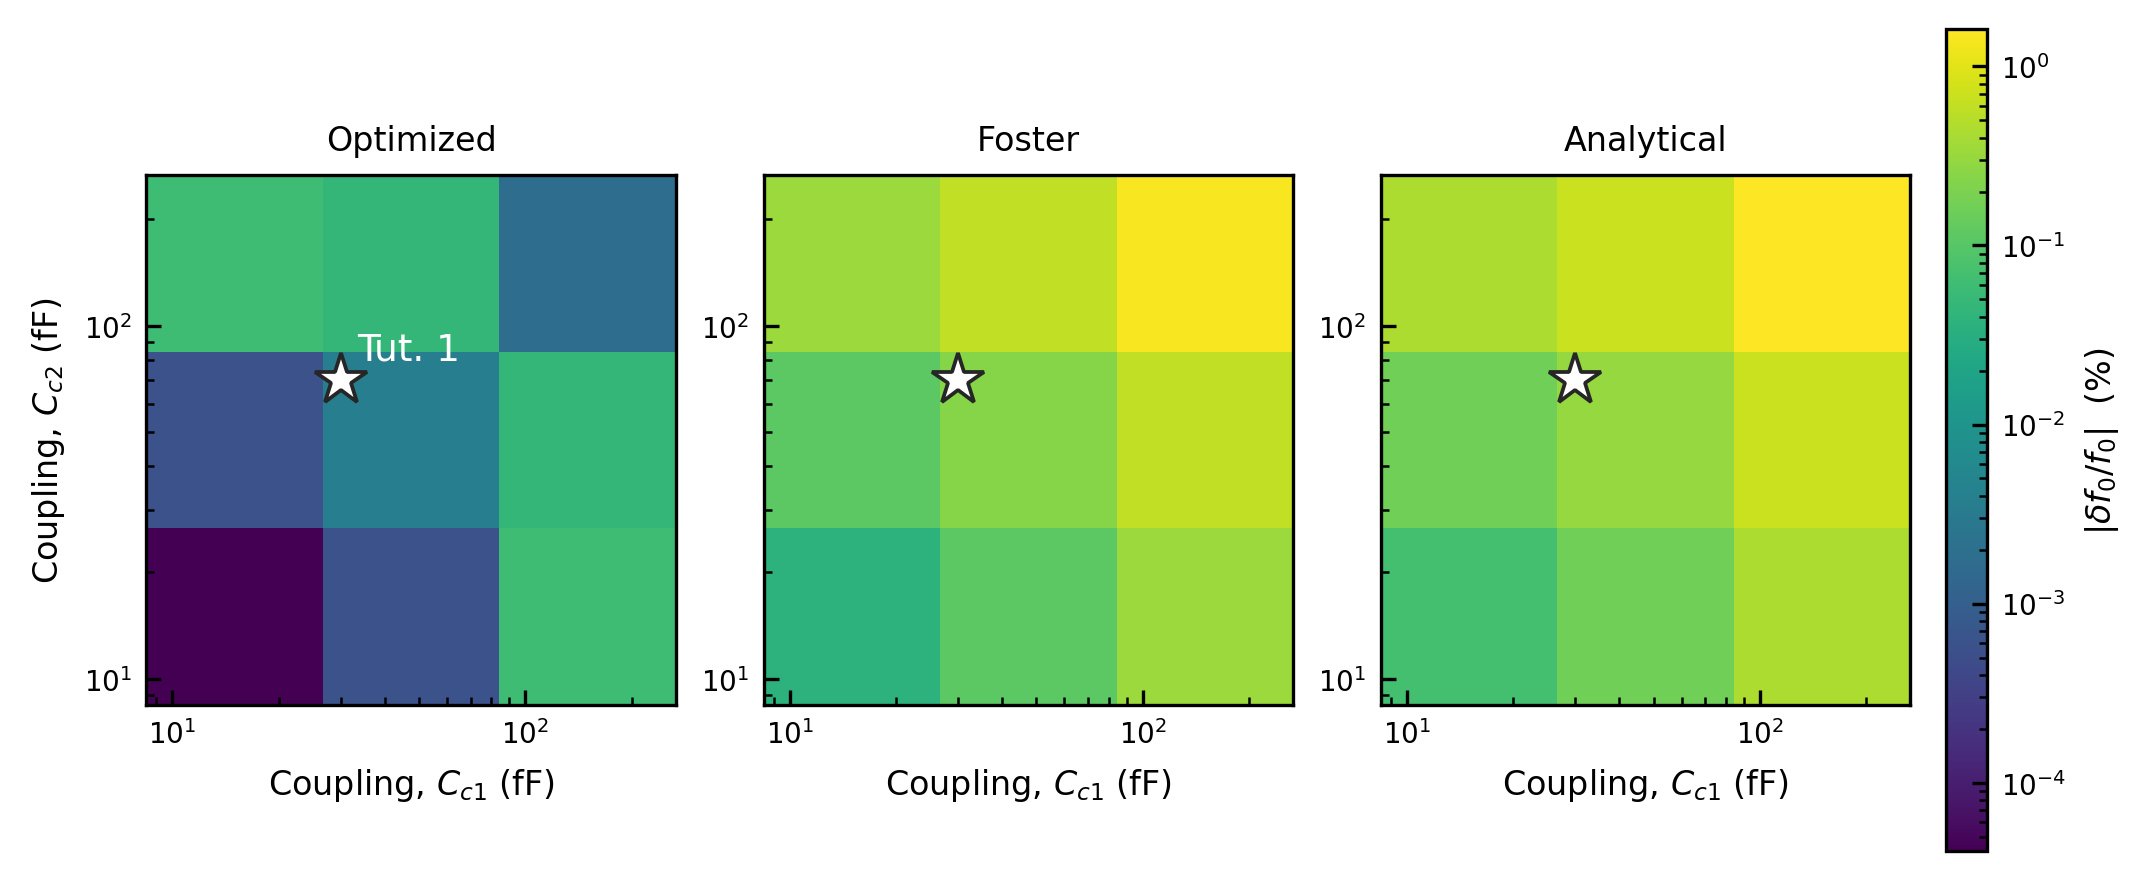

In [6]:
fig, axes = sl.plot_heatmaps(
    cc * 1e15, cc * 1e15,
    {sl.MODEL_LABELS[m]: np.abs(f0_err[m]) for m in MODELS},
    xlabel=sl.axis_label("Coupling", r"C_{c1}", "fF"),
    ylabel=sl.axis_label("Coupling", r"C_{c2}", "fF"),
    cbar_label=r"$|\delta f_0/f_0|$  (%)",
    norm="log",
    show=False,
)
for k, ax in enumerate(np.atleast_1d(axes)):
    ax.plot(30, 70, marker="*", ms=13, mfc="w", mec="0.15", mew=0.9, ls="none")
    if k == 0:
        ax.annotate("Tut. 1", (30, 70), xytext=(4, 5), textcoords="offset points",
                    color="w", fontsize=9)
plt.show()


The **Optimized** method tracks the CPW to a few *thousandths* of a percent
over most of the plane — never worse than $0.06\%$, at the strongly asymmetric
corners (15 fF against 150 fF) — while the other two, which do not inherently
incorporate the loading, do not.

The Foster and Analytical errors instead grow with the *total* coupling, reaching
$\approx 1.5\%$ at the strongest symmetric point (150 fF on both ports).


## 2. Predicting the loaded frequency shift

The point of a fitted `(L, C)` is to *stand in* for the resonator when
something else is attached to it. So to test this we attach a load and ask whether each model
reproduces how far the CPW resonance moves.

For this part of the tutorial we'll choose just one device, strong, asymmetric regime ($C_{c1}=60$,
$C_{c2}=35$ fF) and add a **100 fF shunt capacitor** on each side — the kind
of capacitive loading a neighbouring element presents. The loaded topology (drawn
below) probes the circuit through weak `cc_port` capacitors (1 fF by default,
exposed as a parameter of the loaded builders), so the measured resonance
belongs to the resonator + coupling + load, not to the 50 $\Omega$
terminations.

**Measure bare and loaded the same way.** The bare reference is the *same*
weak-probe topology with a negligible load, so the shift

$$\Delta f = f_0^{\text{loaded}} - f_0^{\text{bare}}, \qquad
  \epsilon = \frac{\Delta f_{\text{LC}} - \Delta f_{\text{CPW}}}{\Delta f_{\text{CPW}}}$$

isolates the *load's* effect. (If you instead compared against the 50 $\Omega$-
terminated bare device of Part 1, the change of probe convention alone would
move $f_0$ by more than the load does — always difference two measurements of
the same circuit convention.) With a clean convention the physics reads off
directly: a shunt-capacitor load adds capacitance, so it *pulls the resonance
down*.




In [7]:
Cc1, Cc2 = 60e-15, 35e-15          # strong, asymmetric design point
Cload = 100e-15                    # shunt-capacitor load on each port side
L_OPEN = 1.0e3                     # open the load inductor -> capacitor-only load
C_NEG = 1e-21                      # negligible load capacitance -> "bare" reference

from pathlib import Path
figdir = Path("figures")
figdir.mkdir(exist_ok=True)
sch = sl.cpw_loaded_schematic_2port(
    d, Cc1, Cc2, Ctog, Ctog, L_OPEN, Cload, L_OPEN, Cload,
    cpw_params=cpw, freq=coarse, Z0=Z0,
    annotations={"load": "100 fF shunt (inductor opened)", "probe": "cc_port = 1 fF"},
    title="Loaded CPW resonator, weak-probe convention",
)
sch.save_svg(figdir / "tut02_loaded_topology.svg")
sch.save_html(figdir / "tut02_loaded_topology.html")
print("saved figures/tut02_loaded_topology.svg|.html")
sch


saved figures/tut02_loaded_topology.svg|.html


Schematic(meta={'title': 'Loaded CPW resonator, weak-probe convention', 'description': '', 'source': 'simpleLOMs.networks.cpw.cpw_resonator_loaded_network_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'resonator', 'label': 'resonator'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50.0}), Component(id='cc_port1', type='cap', label='C_{p1}', value='1.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 1e-15}), Component(id='load1', type='lc', label='load 1', value='L = 1.00 kH\nC = 100.00 fF', ports=['a', 'gnd'], group='load', orient='shunt', props={'L': 1000.0, 'C': 1e-13}), Component(id='Cc1', type='cap', label='C_{c1}', value='60.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 6e-14}), Component(id='Ctog1', type='cap', label='C_{tog1}', value='10.00 fF', ports=['a', 'gnd'], group='resonator', orient='shunt', props={'C': 1e-14}), Component(id='TL', type='tline', label='CPW', value='\\ell = 7.00 mm', ports=['in', 'out'], group='resonator', orient='series', props={'length': 0.007, 'Z0': 46.426279489739365}), Component(id='Ctog2', type='cap', label='C_{tog2}', value='10.00 fF', ports=['a', 'gnd'], group='resonator', orient='shunt', props={'C': 1e-14}), Component(id='Cc2', type='cap', label='C_{c2}', value='35.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 3.5e-14}), Component(id='load2', type='lc', label='load 2', value='L = 1.00 kH\nC = 100.00 fF', ports=['a', 'gnd'], group='load', orient='shunt', props={'L': 1000.0, 'C': 1e-13}), Component(id='cc_port2', type='cap', label='C_{p2}', value='1.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 1e-15}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50.0})], nets=[Net(id='n1', ports=['P1.out', 'cc_port1.a']), Net(id='n2', ports=['cc_port1.b', 'load1.a']), Net(id='n3', ports=['load1.gnd', 'GND']), Net(id='n4', ports=['cc_port1.b', 'Cc1.a']), Net(id='n5', ports=['Cc1.b', 'Ctog1.a']), Net(id='n6', ports=['Ctog1.gnd', 'GND']), Net(id='n7', ports=['Cc1.b', 'TL.in']), Net(id='n8', ports=['TL.out', 'Ctog2.a']), Net(id='n9', ports=['Ctog2.gnd', 'GND']), Net(id='n10', ports=['TL.out', 'Cc2.a']), Net(id='n11', ports=['Cc2.b', 'load2.a']), Net(id='n12', ports=['load2.gnd', 'GND']), Net(id='n13', ports=['Cc2.b', 'cc_port2.a']), Net(id='n14', ports=['cc_port2.b', 'P2.in'])], annotations={'load': '100 fF shunt (inductor opened)', 'probe': 'cc_port = 1 fF'})

We first fit all three models on the bare, 50-ohm terminated device.


In [8]:
def measure_f0(build):
    """Locate a resonance by its |S21| peak (wide grid), then circle-fit f0 on a
    fine local grid. Robust for the sharp, weakly-probed resonances here."""
    wide = rf.Frequency(5.0e9, 9.5e9, 9_001, unit="Hz")
    f_approx = wide.f[np.argmax(np.abs(build(wide).s[:, 1, 0]))]
    fine = rf.Frequency(f_approx - 60e6, f_approx + 60e6, 20_001, unit="Hz")
    f0, _ = sl.circle_fit_f0_kappa(build(fine), 0, 0)
    return f0

models = {m: sl.fit_lom(d, model=m, Cc1=Cc1, Cc2=Cc2, Ctog=Ctog, Z0=Z0,
                        cpw_params=cpw, freq=coarse, return_model=True)
          for m in MODELS}


Now we can determine the shift in frequency when comparing the bare and loaded CPWs. This acts as the ground truth for the comparsion.

In [9]:
b_cpw = lambda fr, C1, C2: sl.cpw_resonator_loaded_network_2port(
    fr, d, Cc1, Cc2, Ctog, Ctog, L_OPEN, C1, L_OPEN, C2, cpw_params=cpw, Z0=Z0)
f0_cpw_bare = measure_f0(lambda fr: b_cpw(fr, C_NEG, C_NEG))
f0_cpw_load = measure_f0(lambda fr: b_cpw(fr, Cload, Cload))
df_cpw = f0_cpw_load - f0_cpw_bare

In [10]:
def lc_builder(m, mod):
    if m == "optimized":   
        return lambda fr, C1, C2: sl.lc_resonator_loaded_network_2port(
            mod.L, mod.C, Cc1, Cc2, L_OPEN, C1, L_OPEN, C2, freq=fr, Z0=Z0)
    return lambda fr, C1, C2: sl.lc_resonator_loaded_network_with_grounds_2port(
        mod.L, mod.C, Cc1, Cc2, Ctog, Ctog, L_OPEN, C1, L_OPEN, C2, freq=fr, Z0=Z0)

rows = [{"model": "CPW (truth)", "f0_bare_GHz": f0_cpw_bare / 1e9,
         "f0_loaded_GHz": f0_cpw_load / 1e9, "shift_MHz": df_cpw / 1e6,
         "loaded_err_MHz": 0.0, "shift_err_%": 0.0}]
for m in MODELS:
    b = lc_builder(m, models[m])
    fb = measure_f0(lambda fr: b(fr, C_NEG, C_NEG))
    fl = measure_f0(lambda fr: b(fr, Cload, Cload))
    df = fl - fb
    rows.append({"model": sl.MODEL_LABELS[m], "f0_bare_GHz": fb / 1e9,
                 "f0_loaded_GHz": fl / 1e9, "shift_MHz": df / 1e6,
                 "loaded_err_MHz": (fl - f0_cpw_load) / 1e6,
                 "shift_err_%": 100.0 * (df - df_cpw) / df_cpw})

loaded = pd.DataFrame(rows).set_index("model")
print(f"100 fF loads pull the CPW resonance {df_cpw/1e6:+.1f} MHz "
      f"({f0_cpw_bare/1e9:.4f} -> {f0_cpw_load/1e9:.4f} GHz)")
loaded.round(4)


100 fF loads pull the CPW resonance -387.1 MHz (8.4354 -> 8.0484 GHz)


,f0_bare_GHz,f0_loaded_GHz,shift_MHz,loaded_err_MHz,shift_err_%
model,,,,,
CPW (truth),8.4354,8.0484,-387.0558,0.0000,0.0000
Optimized,8.4469,8.0487,-398.2113,0.3463,2.8822
Foster,8.4354,8.0583,-377.0917,9.9430,-2.5743
Analytical,8.4366,8.0624,-374.2112,14.0569,-3.3185


Now we can compare the bare vs loaded CPW resonance.


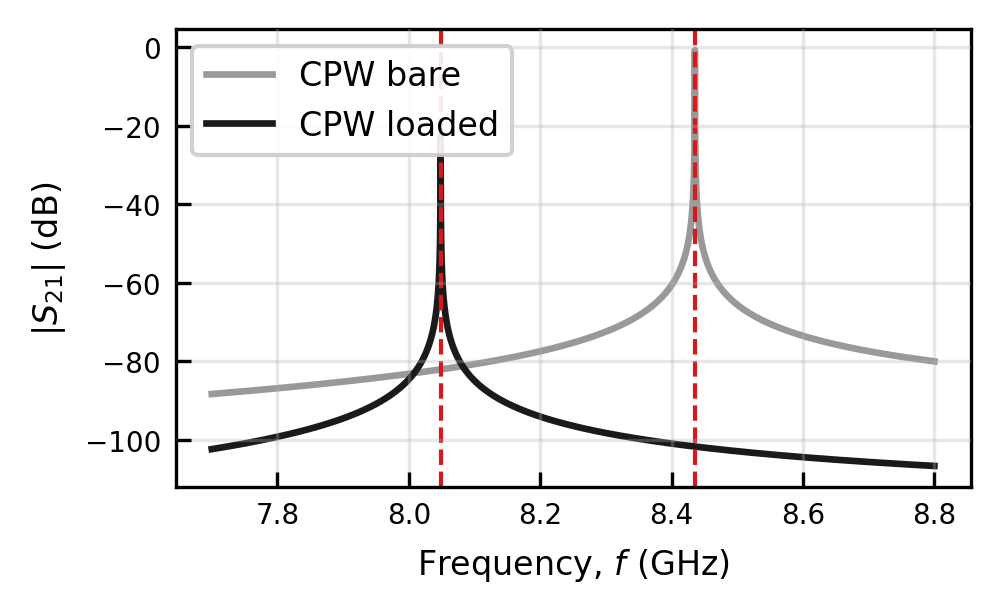

Delta f = -387.1 MHz


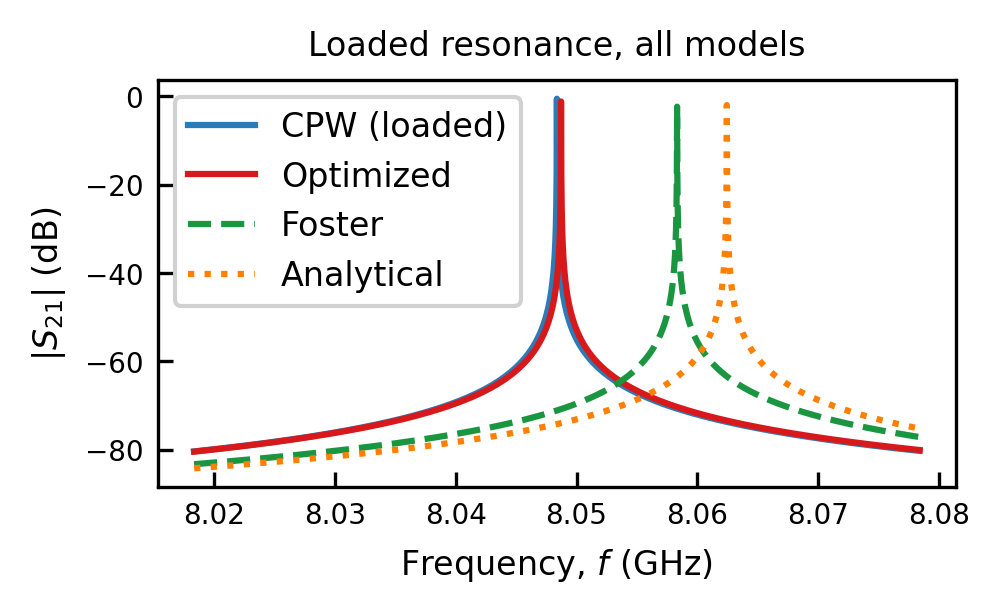

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: title={'center': 'Loaded resonance, all models'}, xlabel='Frequency, $f$ (GHz)', ylabel='$|S_{21}|$ (dB)'>)

In [11]:
wide = rf.Frequency(7.7e9, 8.8e9, 12_001, unit="Hz")
s_db = lambda net: 20 * np.log10(np.abs(net.s[:, 1, 0]))
sl.plot_curves(
    None,
    (wide.f / 1e9, s_db(b_cpw(wide, C_NEG, C_NEG)), "CPW bare", dict(color="0.6", lw=1.6)),
    (wide.f / 1e9, s_db(b_cpw(wide, Cload, Cload)), "CPW loaded", dict(color="0.1", lw=1.6)),
    xlabel=sl.LABEL_FREQ,
    ylabel=r"$|S_{21}|$ (dB)",
    vline=[f0_cpw_bare / 1e9, f0_cpw_load / 1e9],
)
print(rf"Delta f = {df_cpw/1e6:+.1f} MHz")

# Zoom on the loaded resonance: each LOM vs the CPW ground truth.
W = rf.Frequency(f0_cpw_load - 30e6, f0_cpw_load + 30e6, 12_001, unit="Hz")
nets = {"CPW (loaded)": b_cpw(W, Cload, Cload)}
for m in MODELS:
    nets[sl.MODEL_LABELS[m]] = lc_builder(m, models[m])(W, Cload, Cload)
sl.plot_all_models(nets, m=1, n=0, quantity="db", title="Loaded resonance, all models")


As we expect, the Optimized model is the best at predicting how the element will behave in a distributed network.